# What is Linear Regression ?

Linear Regression learns the best values of the weight (w) and bias (b) in the equation y=wx+b by minimizing the Mean Squared Error (MSE) loss using Gradient Descent, allowing it to predict continuous numerical values from input features.

# Some Common terms

### Feature (X)

This is the input to the model.

Think of it as the information you already know.

Example:

* House Size
* Hours Studied
* Years of Experience

The model uses features to make predictions.

---

#### Label (Y)

This is the correct answer.

It is what the model is trying to learn and predict.

Example:

* House Price
* Exam Marks
* Salary

---

#### Dataset

A dataset is a collection of features and labels.

Think of it as a spreadsheet where each row is one example.

Example:

| Hours | Marks |
| ----- | ----- |
| 2     | 40    |
| 4     | 60    |
| 6     | 80    |

---

#### Model

A model is the mathematical function that learns patterns from data.

Think of it as a smart calculator.

Give it an input,

it gives you a prediction.

---

#### Parameter

Parameters are values the model learns automatically.

For Linear Regression,

they are:

* Weight (w)
* Bias (b)

Training means finding the best values of these parameters.

---

#### Hyperparameter

Hyperparameters are settings that **you choose**, not the model.

Examples:

* Learning Rate
* Epochs
* Batch Size

The model doesn't learn them.

You decide them before training.

---

#### Prediction (ŷ)

Prediction is the output produced by the model.

Example

Hours Studied = 6

Prediction = 78 Marks

The prediction may or may not be correct.

---

#### Error

Error is simply the difference between the actual value and the predicted value.

Example

Actual = 80

Predicted = 75

Error = 5

Smaller error means better predictions.

---

#### Loss Function

A loss function measures how wrong the model is.

Think of it as a report card.

High Loss

→ Poor model

Low Loss

→ Good model

The model tries to make the loss as small as possible.

---

#### Cost Function

Cost Function is the average loss over the entire dataset.

Loss can be for one prediction.

Cost looks at all predictions together.

Training tries to minimize the cost.

---

#### Mean Squared Error (MSE)

MSE is the most common loss function for Linear Regression.

It squares every error,

adds them together,

and takes the average.

Large mistakes are punished more than small ones.

---

#### Weight (w)

Weight decides how much the input affects the output.

Think of it as the **importance** of a feature.

Larger weight

→ Bigger impact on prediction.

---

#### Bias (b)

Bias is a constant added to every prediction.

Think of it as moving the entire prediction line up or down.

Without bias,

the model becomes much less flexible.

---

#### Gradient

A gradient tells us

how much the loss changes

when we change a parameter.

Think of it as a GPS arrow

showing which direction reduces the error.

---

#### Gradient Descent

This is the learning algorithm.

Imagine standing on a mountain.

Your goal is to reach the bottom.

The gradient tells you

which direction goes downhill.

Gradient Descent keeps taking small downhill steps

until it reaches the lowest point (minimum loss).

---

#### Learning Rate

Learning Rate decides

how big each downhill step should be.

Small Learning Rate

→ Slow learning.

Large Learning Rate

→ Fast but may overshoot.

A good learning rate balances speed and stability.

---

#### Optimizer

An optimizer is the algorithm

that updates the model's parameters.

Think of it as the worker

that actually changes the weights after seeing the gradients.

Examples:

* SGD
* Adam

---

#### Epoch

One epoch means

the model has seen the **entire training dataset once**.

If your dataset has 1000 samples,

reading all 1000 samples

=

1 Epoch.

---

#### Batch

Instead of training on the whole dataset at once,

we divide it into smaller pieces.

Each small piece is called a batch.

Example:

1000 samples

Batch Size = 100

Total Batches = 10

---

#### Batch Size

Batch Size is

the number of samples processed together before updating the model.

Small Batch Size

→ More updates

Large Batch Size

→ Fewer updates

---

#### Iteration

One iteration means

processing **one batch** and updating the model once.

Example

1000 samples

Batch Size = 100

Iterations per Epoch = 10

---

#### Forward Pass

The Forward Pass is when

the model takes the input,

applies its equation,

and produces a prediction.

Nothing is learned yet.

It is simply making predictions.

---

#### Backward Pass (Backpropagation)

After calculating the loss,

the model works backwards

to find how each weight contributed to the error.

This process computes the gradients.

Think of it as finding

**who is responsible for the mistake.**

---

#### Convergence

Convergence happens

when the loss stops decreasing significantly.

At this point,

the model has learned as much as it reasonably can.

---

#### Inference

Inference means

using a trained model to make predictions on new data.

No learning happens.

The model only predicts.

---

#### Overfitting

Overfitting happens

when the model memorizes the training data

instead of learning the underlying pattern.

It performs well on training data

but poorly on new data.

Think of a student who memorizes answers

instead of understanding concepts.

---

#### Underfitting

Underfitting happens

when the model is too simple

to learn the pattern in the data.

It performs poorly

on both training and testing data.

Think of a student

who didn't study enough.

---

#### Generalization

Generalization is the model's ability

to make accurate predictions

on data it has never seen before.

A good model doesn't memorize—

it understands patterns.




In [13]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [14]:
start = 0
stop = 10
step = 0.02

x_features = torch.arange(start, stop, step, device=device).unsqueeze(1)  # Example input features
x_features.shape, x_features[:5]


(torch.Size([500, 1]),
 tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]], device='cuda:0'))

In [15]:
weights = torch.randn(1, device=device)  # Random weight initialization
bias = torch.randn(1, device=device)  # Random bias initialization

weights, bias

(tensor([0.6328], device='cuda:0'), tensor([-0.9523], device='cuda:0'))

In [16]:
y_predicted = weights * x_features + bias  # Linear regression model


In [17]:
from torch.utils.data import TensorDataset, DataLoader

# Create synthetic linear data with noise and split into training/test sets.
true_w = 2.0
true_b = 5.0
noise = torch.randn_like(x_features) * 1.0

y_labels = true_w * x_features + true_b + noise

data_size = x_features.size(0)
train_size = int(0.8 * data_size)
perm = torch.randperm(data_size, device=device)

train_indices = perm[:train_size]
test_indices = perm[train_size:]

train_features = x_features[train_indices]
train_labels = y_labels[train_indices]
test_features = x_features[test_indices]
test_labels = y_labels[test_indices]

# Use detached CPU tensors so multiprocessing workers can serialize the dataset safely.
train_features_ds = train_features.detach().cpu()
train_labels_ds = train_labels.detach().cpu()
test_features_ds = test_features.detach().cpu()
test_labels_ds = test_labels.detach().cpu()

train_dataset = TensorDataset(train_features_ds, train_labels_ds)
test_dataset = TensorDataset(test_features_ds, test_labels_ds)

BATCH_SIZE = 50
NUM_WORKERS = 2

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)


In [18]:
print(len(train_loader), len(test_loader) , len(train_dataset), len(test_dataset))

8 2 400 100


One-line Summary
TensorDataset → Combines features and labels into a dataset where each input stays paired with its correct output.

DataLoader → Loads the dataset in small batches and feeds them to the model during training.

Batch Size → Number of samples processed before updating the model's weights.

Shuffle → Randomizes the order of training samples each epoch to improve learning.

num_workers → Number of CPU processes that prepare batches in parallel to speed up data loading.

In [19]:
for train_batch_features, train_batch_labels in train_loader:
    train_batch_features = train_batch_features.to(device)
    train_batch_labels = train_batch_labels.to(device)
    print(f"Train batch features: {train_batch_features.shape}, Train batch labels: {train_batch_labels.shape}")
    break  # Just to show the first batch


Train batch features: torch.Size([50, 1]), Train batch labels: torch.Size([50, 1])


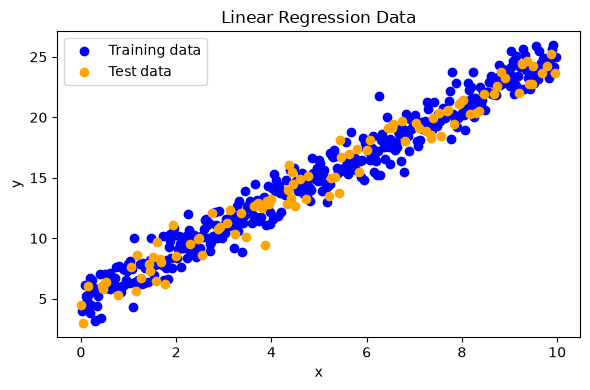

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(train_features.detach().cpu().numpy(), train_labels.detach().cpu().numpy(), color='blue', label='Training data')
plt.scatter(test_features.detach().cpu().numpy(), test_labels.detach().cpu().numpy(), color='orange', label='Test data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Data')
plt.legend()
plt.tight_layout()
plt.show()
